## Benchmarking Predictions

In this section, we benchmark the model's performance on synthetic data of varying sequence lengths. Specifically, we'll measure:
1. Inference time
2. Allocated RAM during inference

Finally, we'll plot the results to visualize how sequence length affects inference time and RAM usage.


In [2]:
import subprocess as sp
import os

def get_gpu_memory():
    command = "nvidia-smi --query-gpu=memory.used --format=csv"
    memory_used_info = sp.check_output(command.split()).decode('ascii').split('\n')[:-1][1:]
    memory_used_values = [int(x.split()[0]) for i, x in enumerate(memory_used_info)]
    return memory_used_values

In [ ]:
baseline_gpu_memory = get_gpu_memory()[0]

In [3]:
from methyldl.modelling.dnabert2 import EpigenDnabert2
from methyldl.modelling.dismir import Dismir
from methyldl.data.dataset import SupervisedDataset, generate_example_data, generate_example_data_for_methylbert
import os
import torch
import time
import matplotlib.pyplot as plt
from tqdm import tqdm
from methyldl.modelling.utils import count_model_parameters
from methyldl.modelling.methylbert import MethylVocab,MethylBertFinetuneDataset, MethylBert, default_methylbert_config
import gc

x:\KULeuven-Masters\Master Thesis\methyldl\methyldl\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import pickle
with open("performance_data.pkl", "rb") as f:
    inference_times, allocated_ram = pickle.load(f)

In [ ]:
# Benchmarking variables
import numpy as np
sequence_lengths = [2**i for i in range(16) if i >5] # [64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]
n_repeats = 10
models = ["DISMIR", "DNABERT2", "MethylBERT", "DISMIR_MINIGRU"]
inference_times = {model: {seq_len: [] for seq_len in sequence_lengths} for model in models}
allocated_ram = {model: {seq_len: [] for seq_len in sequence_lengths} for model in models}
inference_times["DISMIR_MINIGRU"] = {seq_len: [] for seq_len in sequence_lengths}
allocated_ram["DISMIR_MINIGRU"] = {seq_len: [] for seq_len in sequence_lengths}
inference_times["DISMIR"] = {seq_len: [] for seq_len in sequence_lengths}
allocated_ram["DISMIR"] = {seq_len: [] for seq_len in sequence_lengths}
from IPython.utils import io


for seq_len in tqdm(sequence_lengths, f"Processing {n_repeats} sequences each of length {sequence_lengths}"):
    for model in models:
        try:
            if model == "DNABERT2":
                predictor = EpigenDnabert2(max_sequence_length=seq_len)
            elif model == "DISMIR":
                predictor = Dismir(seq_len, "", "", "")
            elif model == "DISMIR_MINIGRU":
                predictor = Dismir(seq_len, "", "", "", flavour="minigru")
            elif model == "MethylBERT":
                methyl_samples_seq_len = len(generate_example_data_for_methylbert(
                    sequence_length=seq_len,
                    include_cpg_methylation=True,
                    include_m6a_methylation=False,
                    include_labels=True,
                    num_samples=1  
                )[1][1])
                predictor = MethylBert(custom_config=default_methylbert_config, 
                            foundation_model_path = "hanyangii/methylbert_hg19_6l",
                            num_labels=2,
                            num_dmr_labels = 100,
                            seq_len=methyl_samples_seq_len) 
                
            else:
                raise ValueError(f"Unexpected model: {model}")

            print(f"Predictor successfully initialized for {model}")
            print(f"Running simulation for {model}. Sequence Length: {seq_len}. Number of parameters: {count_model_parameters(predictor.model)}")

            for i in range(n_repeats):
                # Generate synthetic data for the given sequence length
                if model == "MethylBERT":
                    synthetic_data = generate_example_data_for_methylbert(
                        sequence_length=seq_len,
                        include_cpg_methylation=True,
                        include_m6a_methylation=True,
                        include_labels=False,
                        num_samples=1  # Single sample per repeat
                    )
                    with io.capture_output() as captured:
                        synthetic_dataset = MethylBertFinetuneDataset(
                            data_source = synthetic_data,
                            vocab=MethylVocab(k=3),
                            seq_len=methyl_samples_seq_len
              )
                else:
                    synthetic_data = generate_example_data(
                        sequence_length=seq_len,
                        include_cpg_methylation=True,
                        include_m6a_methylation=True,
                        include_labels=False,
                        num_samples=1  # Single sample per repeat
                    )

                # Measure inference time and allocated RAM
                start_time = time.time()
                torch.cuda.reset_peak_memory_stats()  # Reset RAM tracking if using GPU
                with io.capture_output() as captured:
                    if model == "DNABERT2":
                        synthetic_dataset = SupervisedDataset(
                            tokenizer=predictor.tokenizer,
                            data_path_or_list=synthetic_data,
                            kmer=-1
                        )
                        predictor.predict(synthetic_dataset,clear_cache=False)
                    elif model in ["DISMIR","DISMIR_MINIGRU"]:
                        dna, c_methylation = synthetic_data[1][0], synthetic_data[1][1]
                        if i>1 and seq_len > 10000 and model == "DISMIR":
                            continue
                        if i>1 and seq_len > 20000 and model == "DISMIR_MINIGRU":
                            continue
                        predictor.predict([dna], [c_methylation], batch_size=1)
                    elif model == "MethylBERT":
                        predictor.predict(synthetic_dataset, clear_cache=False)
                

                elapsed_time = time.time() - start_time
                peak_ram = get_gpu_memory()[0] - baseline_gpu_memory # RAM in MB

                inference_times[model][seq_len].append(elapsed_time)
                allocated_ram[model][seq_len].append(peak_ram)

                if 'synthetic_dataset' in globals():
                    del synthetic_dataset
                torch.cuda.empty_cache()
                gc.collect()


        except Exception as e:
            print(f"Error initializing predictor for model {model} with sequence length {seq_len}: {e}")

### Visualizing Benchmark Results

Finally, we'll plot:
1. **Sequence Length vs Inference Time**
2. **Sequence Length vs Allocated RAM**

These plots help us understand the performance characteristics of EpigenDnabert2.

In [5]:
import pickle
# data_tuple = (inference_times, allocated_ram)
# with open("performance_data.pkl", "wb") as f:
#     pickle.dump(data_tuple, f)

In [6]:
with open("performance_data_original.pkl", "rb") as f:
    data_tuple = pickle.load(f)

In [ ]:
# with open("performance_data_original.pkl", "wb") as f:
#     pickle.dump((inference_times,allocated_ram),f)

In [7]:
inference_times = data_tuple[0]
allocated_ram = data_tuple[1]

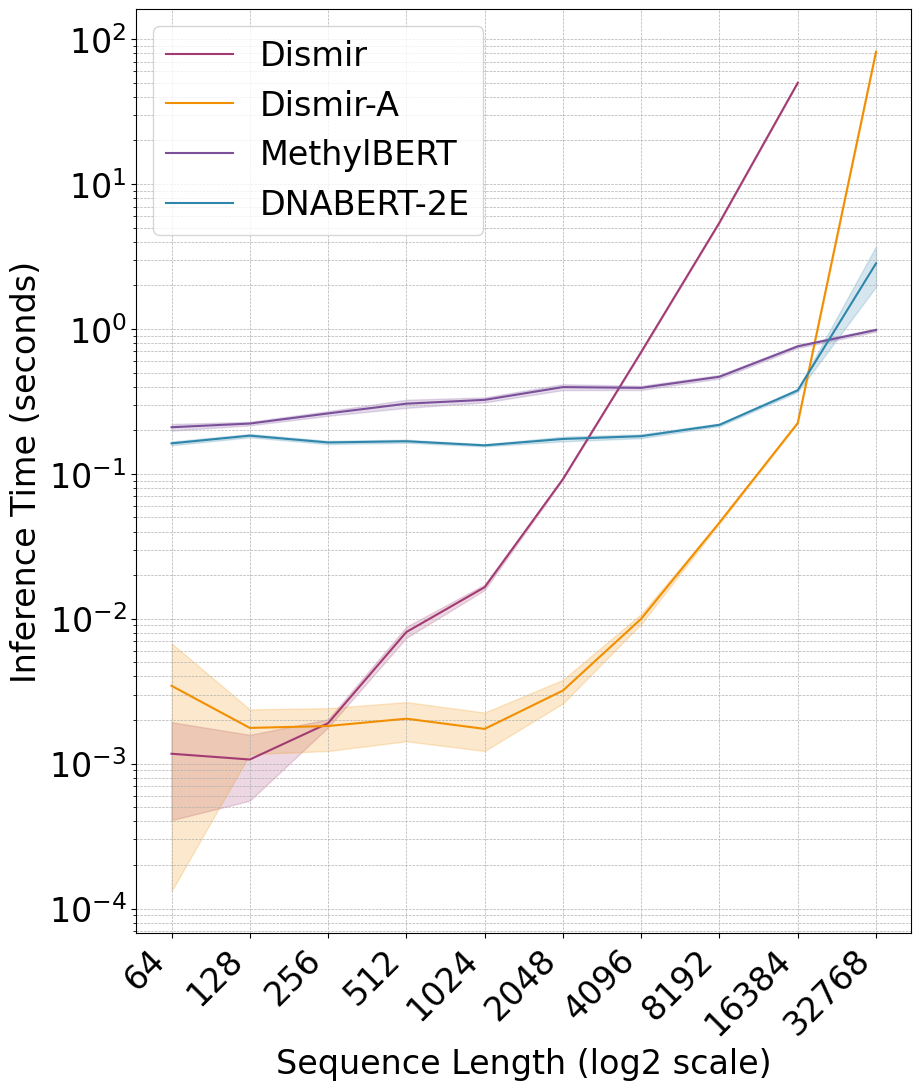

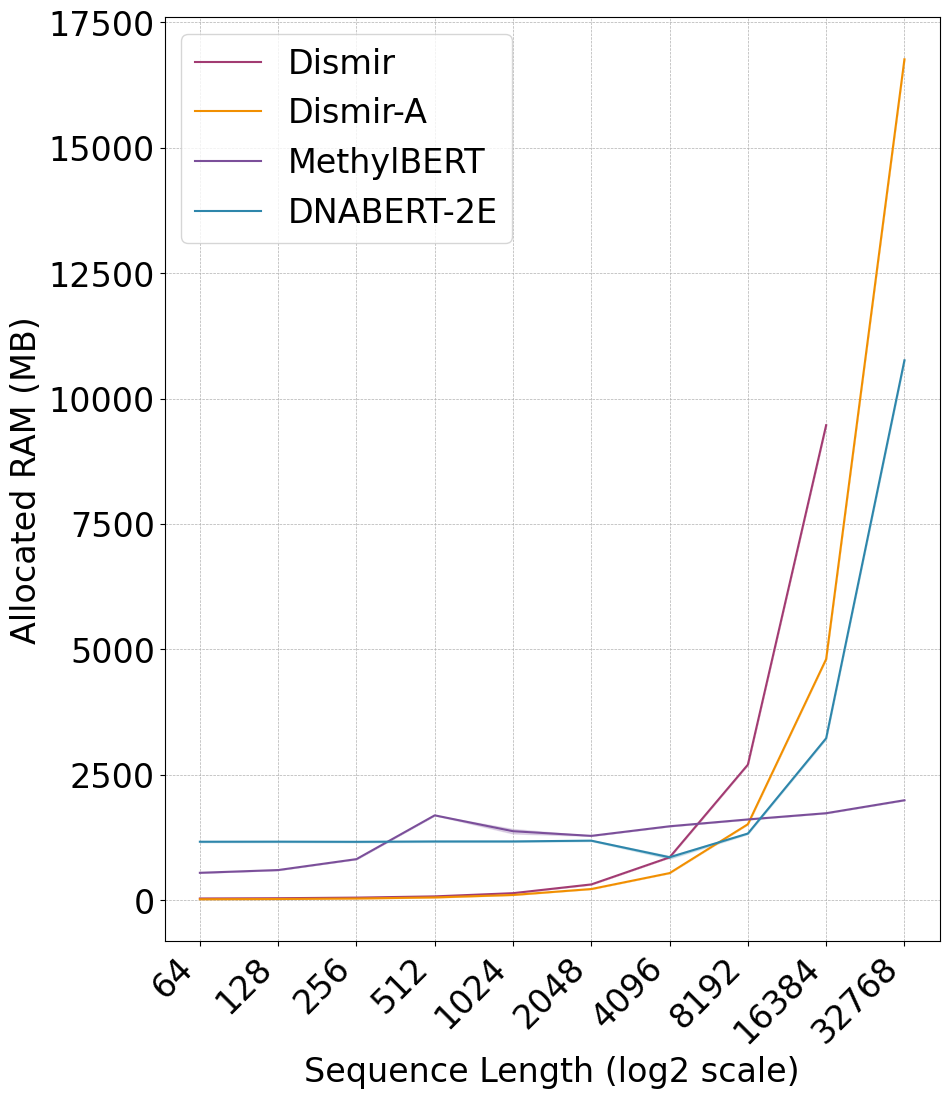

In [8]:
import numpy as np
import matplotlib.pyplot as plt

sequence_lengths = [2**i for i in range(16) if i >5]

def plot_benchmark_results(inference_times, allocated_ram, sequence_lengths, log_scale=True,fontsize=24):
    """
    Plots inference time and allocated RAM as line plots with shaded 95% confidence intervals.
    
    Parameters:
        inference_times (dict): Dictionary with inference times for each model and sequence length.
        allocated_ram (dict): Dictionary with allocated RAM for each model and sequence length.
        sequence_lengths (list): List of sequence lengths tested.
        log_scale (bool): Whether to use a log scale for the y-axis.
    """
    models = list(inference_times.keys())
    models = [models[i] for i in [0,3,2,1]]
    # colors = plt.cm.tab10(range(len(models)))  # Assign distinct colors to models


    # Convert sequence lengths to log2 scale for x-axis
    log_seq_lengths = np.log2(sequence_lengths)

    # --- Inference Time Plot ---
    models_labels = ["Dismir", "DNABERT-2E", "MethylBERT", "Dismir-A"]

    colors = ['#A23B72', '#2E86AB', '#7B4F9A','#F18F01']
    # Function to compute mean and confidence interval
    def mean_and_confidence(data_list):
        means = [np.mean(seq) if len(seq) > 0 else np.nan for seq in data_list]
        std_errs = [np.std(seq) / np.sqrt(len(seq)) if len(seq) > 1 else np.nan for seq in data_list]
        conf_intervals = [1.96 * se if not np.isnan(se) else np.nan for se in std_errs]
        return np.array(means), np.array(conf_intervals)

    plt.figure(figsize=(10, 12))
    for model, i in zip(models, [0,3,2,1]):
        data_list = [inference_times[model][seq_len] for seq_len in sequence_lengths]
        
        if any(len(d) > 0 for d in data_list):  # Ensure there's valid data
            mean, conf = mean_and_confidence(data_list)

            plt.plot(log_seq_lengths, mean, label=models_labels[i], color=colors[i])
            plt.fill_between(log_seq_lengths, mean - conf, mean + conf, color=colors[i], alpha=0.2)

    plt.xlabel("Sequence Length (log2 scale)", fontsize=fontsize)
    plt.ylabel("Inference Time (seconds)", fontsize=fontsize)
    # plt.title("Sequence Length vs Inference Time", fontsize=fontsize)
    plt.xticks(log_seq_lengths, sequence_lengths, rotation=45, ha='right', fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.grid(which="both", linestyle="--", linewidth=0.5)
    
    if log_scale:
        plt.yscale("log")

    plt.legend(loc="upper left", fontsize=fontsize)
    plt.show()

    # --- Allocated RAM Plot ---
    plt.figure(figsize=(10, 12))
    for model, i in zip(models, [0,3,2,1]):
            data_list = [allocated_ram[model][seq_len] for seq_len in sequence_lengths]
            
            if any(len(d) > 0 for d in data_list):  # Ensure there's valid data
                mean, conf = mean_and_confidence(data_list)

                plt.plot(log_seq_lengths, mean, label=models_labels[i], color=colors[i])
                plt.fill_between(log_seq_lengths, mean - conf, mean + conf, color=colors[i], alpha=0.2)

    plt.xlabel("Sequence Length (log2 scale)", fontsize=fontsize)
    plt.ylabel("Allocated RAM (MB)", fontsize=fontsize)
    # plt.title("Sequence Length vs Allocated RAM", fontsize=fontsize)
    plt.xticks(log_seq_lengths, sequence_lengths, rotation=45, ha='right', fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.grid(which="both", linestyle="--", linewidth=0.5)
    
    # if log_scale:
    #     plt.yscale("log")

    plt.legend(loc="upper left", fontsize=fontsize)
    plt.show()

# Example usage:
plot_benchmark_results(inference_times, allocated_ram, sequence_lengths, log_scale=True)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

sequence_lengths = [2**i for i in range(16) if i >5]

def plot_benchmark_results(inference_times, allocated_ram, sequence_lengths, log_scale=True):
    """
    Plots inference time and allocated RAM as line plots with shaded 95% confidence intervals.
    
    Parameters:
        inference_times (dict): Dictionary with inference times for each model and sequence length.
        allocated_ram (dict): Dictionary with allocated RAM for each model and sequence length.
        sequence_lengths (list): List of sequence lengths tested.
        log_scale (bool): Whether to use a log scale for the y-axis.
    """
    models = list(inference_times.keys())
    models = [models[i] for i in [0,3,2,1]]
    colors = plt.cm.tab10(range(len(models)))  # Assign distinct colors to models


    # Convert sequence lengths to log2 scale for x-axis
    log_seq_lengths = np.log2(sequence_lengths)

    # --- Inference Time Plot ---
    models_labels = ["DISMIR", "DNABERT2 Extended (ours)", "MethylBERT", "DISMIR Accelerated (ours)"]

    # Function to compute mean and confidence interval
    def mean_and_confidence(data_list):
        means = [np.mean(seq) if len(seq) > 0 else np.nan for seq in data_list]
        std_errs = [np.std(seq) / np.sqrt(len(seq)) if len(seq) > 1 else np.nan for seq in data_list]
        conf_intervals = [1.96 * se if not np.isnan(se) else np.nan for se in std_errs]
        return np.array(means), np.array(conf_intervals)

    plt.figure(figsize=(10, 6))
    for model, i in zip(models, [0,3,2,1]):
        data_list = [inference_times[model][seq_len] for seq_len in sequence_lengths]
        
        if any(len(d) > 0 for d in data_list):  # Ensure there's valid data
            mean, conf = mean_and_confidence(data_list)

            plt.plot(log_seq_lengths, mean, label=models_labels[i], color=colors[i])
            plt.fill_between(log_seq_lengths, mean - conf, mean + conf, color=colors[i], alpha=0.2)

    plt.xlabel("Sequence Length (log2 scale)", fontsize=20)
    plt.ylabel("Inference Time (seconds)", fontsize=20)
    plt.title("Sequence Length vs Inference Time", fontsize=20)
    plt.xticks(log_seq_lengths, sequence_lengths, rotation=45, ha='right', fontsize=20)
    plt.yticks(fontsize=20)
    plt.grid(which="both", linestyle="--", linewidth=0.5)
    
    if log_scale:
        plt.yscale("log")

    plt.legend(loc="upper left", fontsize=20)
    plt.show()

    # --- Allocated RAM Plot ---
    plt.figure(figsize=(10, 6))
    for model, i in zip(models, [0,3,2,1]):
            data_list = [allocated_ram[model][seq_len] for seq_len in sequence_lengths]
            
            if any(len(d) > 0 for d in data_list):  # Ensure there's valid data
                mean, conf = mean_and_confidence(data_list)

                plt.plot(log_seq_lengths, mean, label=models_labels[i], color=colors[i])
                plt.fill_between(log_seq_lengths, mean - conf, mean + conf, color=colors[i], alpha=0.2)

    plt.xlabel("Sequence Length (log2 scale)", fontsize=20)
    plt.ylabel("Allocated RAM (MB)", fontsize=20)
    plt.title("Sequence Length vs Allocated RAM", fontsize=20)
    plt.xticks(log_seq_lengths, sequence_lengths, rotation=45, ha='right', fontsize=20)
    plt.yticks(fontsize=20)
    plt.grid(which="both", linestyle="--", linewidth=0.5)
    
    # if log_scale:
    #     plt.yscale("log")

    plt.legend(loc="upper left", fontsize=20)
    plt.show()

# Example usage:
plot_benchmark_results(inference_times, allocated_ram, sequence_lengths, log_scale=True)


### Running Pytroch Profiler

In [ ]:
sequence_lengths = [2**i for i in range(16) if i >5]

In [ ]:
from torch.profiler import profile, record_function, ProfilerActivity

In [ ]:
if torch.cuda.is_available():
    device = 'cuda'
seq_len = sequence_lengths[-1]
synthetic_data = generate_example_data(
                        sequence_length=seq_len,
                        include_cpg_methylation=True,
                        include_m6a_methylation=True,
                        include_labels=False,
                        num_samples=1  # Single sample per repeat
                    )
predictor = Dismir(seq_len, "", "", "", flavour="minigru")
dna, c_methylation = synthetic_data[1][0], synthetic_data[1][1]
predictor.model = predictor.model.to(device)


In [ ]:
predictor.predict([dna], [c_methylation], batch_size=1)

In [ ]:
sort_by_keyword = device + "_time_total"

In [ ]:
with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], record_shapes=True,profile_memory=True) as prof:
    with record_function("model_inference"):
        predictor.predict([dna], [c_methylation], batch_size=1)

In [ ]:
prof.key_averages().total_average().cpu_time
prof.key_averages().total_average().device_memory_usage  //1024**2

In [ ]:
prof.key_averages().total_average()

In [ ]:
print(prof.key_averages().table(row_limit=100))

### Benchmarking throughput

In [2]:
import torch
import numpy as np
import time
from tqdm import tqdm
import gc
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
import multiprocessing
from collections import defaultdict
import psutil
import GPUtil
import pandas as pd

### Estimating batch sizes for different models

In [1]:
batch_sizes = [
  {
    "model":"DNABERT2M6A",
    "seq_len":32768,
    "VRAM": 10,
    "batch_size": 1
    },
  {
    "model":"DNABERT2M6A",
    "seq_len":16384,
    "VRAM": 10,
    "batch_size": 4
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":16384,
    "VRAM": 8,
    "batch_size": 3
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":16384,
    "VRAM": 6,
    "batch_size": 2
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":16384,
    "VRAM": 4,
    "batch_size": 1
    },
  
  {
    "model":"DNABERT2M6A",
    "seq_len":8192,
    "VRAM": 10,
    "batch_size": 15
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":8192,
    "VRAM": 8,
    "batch_size": 12
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":8192,
    "VRAM": 6,
    "batch_size": 8
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":8192,
    "VRAM": 4,
    "batch_size": 5
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":8192,
    "VRAM": 2,
    "batch_size": 2
    },     


  
  {
    "model":"DNABERT2M6A",
    "seq_len":4096,
    "VRAM": 10,
    "batch_size": 58
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":4096,
    "VRAM": 8,
    "batch_size": 46
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":4096,
    "VRAM": 6,
    "batch_size": 33
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":4096,
    "VRAM": 4,
    "batch_size": 21
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":4096,
    "VRAM": 2,
    "batch_size": 8
    },     


  {
    "model":"DNABERT2M6A",
    "seq_len":2048,
    "VRAM": 10,
    "batch_size": 210
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":2048,
    "VRAM": 8,
    "batch_size": 163
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":2048,
    "VRAM": 6,
    "batch_size": 111
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":2048,
    "VRAM": 4,
    "batch_size": 68
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":2048,
    "VRAM": 2,
    "batch_size": 31
    },     
  
  {
    "model":"DNABERT2M6A",
    "seq_len":1024,
    "VRAM": 10,
    "batch_size": 556
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":1024,
    "VRAM": 8,
    "batch_size": 458
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":1024,
    "VRAM": 6,
    "batch_size": 350
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":1024,
    "VRAM": 4,
    "batch_size": 222
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":1024,
    "VRAM": 2,
    "batch_size": 102
    },     

  
  {
    "model":"DNABERT2M6A",
    "seq_len":512,
    "VRAM": 10,
    "batch_size": 1290
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":512,
    "VRAM": 8,
    "batch_size": 1074
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":512,
    "VRAM": 6,
    "batch_size": 832
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":512,
    "VRAM": 4,
    "batch_size": 548
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":512,
    "VRAM": 2,
    "batch_size": 246
    },     


  
  {
    "model":"DNABERT2M6A",
    "seq_len":256,
    "VRAM": 10,
    "batch_size": 3230
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":256,
    "VRAM": 8,
    "batch_size": 2620
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":256,
    "VRAM": 6,
    "batch_size": 1960
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":256,
    "VRAM": 4,
    "batch_size": 1270
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":256,
    "VRAM": 2,
    "batch_size": 580
    }, 



  
  {
    "model":"DNABERT2M6A",
    "seq_len":128,
    "VRAM": 10,
    "batch_size": 6180
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":128,
    "VRAM": 8,
    "batch_size": 5150
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":128,
    "VRAM": 6,
    "batch_size": 3992
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":128,
    "VRAM": 4,
    "batch_size": 2640
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":128,
    "VRAM": 2,
    "batch_size": 1120
    }, 


  
  {
    "model":"DNABERT2M6A",
    "seq_len":64,
    "VRAM": 10,
    "batch_size": 12350
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":64,
    "VRAM": 8,
    "batch_size": 9620
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":64,
    "VRAM": 6,
    "batch_size": 7615
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":64,
    "VRAM": 4,
    "batch_size": 4940
    },
    {
    "model":"DNABERT2M6A",
    "seq_len":64,
    "VRAM": 2,
    "batch_size": 2200
    }, 


    {
    "model":"MethylBERT",
    "seq_len":512,
    "VRAM": 10,
    "batch_size": 445
    },
    {
    "model":"MethylBERT",
    "seq_len":512,
    "VRAM": 8,
    "batch_size": 370
    },
    {
    "model":"MethylBERT",
    "seq_len":512,
    "VRAM": 6,
    "batch_size": 287
    },
    {
    "model":"MethylBERT",
    "seq_len":512,
    "VRAM": 4,
    "batch_size": 189
    },
    {
    "model":"MethylBERT",
    "seq_len":512,
    "VRAM": 2,
    "batch_size": 80
    },    


   {
    "model":"MethylBERT",
    "seq_len":256,
    "VRAM": 10,
    "batch_size": 1200
    },
  {
    "model":"MethylBERT",
    "seq_len":256,
    "VRAM": 8,
    "batch_size": 999
    },
    {
    "model":"MethylBERT",
    "seq_len":256,
    "VRAM": 6,
    "batch_size": 774
    },
    {
    "model":"MethylBERT",
    "seq_len":256,
    "VRAM": 4,
    "batch_size": 510
    },
    {
    "model":"MethylBERT",
    "seq_len":256,
    "VRAM": 2,
    "batch_size": 216
    },

{
    "model":"MethylBERT",
    "seq_len":128,
    "VRAM": 10,
    "batch_size": 2400
    },
  {
    "model":"MethylBERT",
    "seq_len":128,
    "VRAM": 8,
    "batch_size": 1999
    },
    {
    "model":"MethylBERT",
    "seq_len":128,
    "VRAM": 6,
    "batch_size": 1548
    },
    {
    "model":"MethylBERT",
    "seq_len":128,
    "VRAM": 4,
    "batch_size": 1020
    },
    {
    "model":"MethylBERT",
    "seq_len":128,
    "VRAM": 2,
    "batch_size": 432
    },


{
    "model":"MethylBERT",
    "seq_len":64,
    "VRAM": 10,
    "batch_size": 4980
    },
  {
    "model":"MethylBERT",
    "seq_len":64,
    "VRAM": 8,
    "batch_size": 4148
    },
    {
    "model":"MethylBERT",
    "seq_len":64,
    "VRAM": 6,
    "batch_size": 3212
    },
    {
    "model":"MethylBERT",
    "seq_len":64,
    "VRAM": 4,
    "batch_size": 2116
    },
    {
    "model":"MethylBERT",
    "seq_len":64,
    "VRAM": 2,
    "batch_size": 896
    },


  {
    "model":"DNABERT2",
    "seq_len":32768,
    "VRAM": 10,
    "batch_size": 1
    },
  {
    "model":"DNABERT2",
    "seq_len":16384,
    "VRAM": 10,
    "batch_size": 4
    },
    {
    "model":"DNABERT2",
    "seq_len":16384,
    "VRAM": 8,
    "batch_size": 3
    },
    {
    "model":"DNABERT2",
    "seq_len":16384,
    "VRAM": 6,
    "batch_size": 2
    },
    {
    "model":"DNABERT2",
    "seq_len":16384,
    "VRAM": 4,
    "batch_size": 1
    },
  
  {
    "model":"DNABERT2",
    "seq_len":8192,
    "VRAM": 10,
    "batch_size": 15
    },
    {
    "model":"DNABERT2",
    "seq_len":8192,
    "VRAM": 8,
    "batch_size": 12
    },
    {
    "model":"DNABERT2",
    "seq_len":8192,
    "VRAM": 6,
    "batch_size": 8
    },
    {
    "model":"DNABERT2",
    "seq_len":8192,
    "VRAM": 4,
    "batch_size": 5
    },
    {
    "model":"DNABERT2",
    "seq_len":8192,
    "VRAM": 2,
    "batch_size": 2
    },     


  
  {
    "model":"DNABERT2",
    "seq_len":4096,
    "VRAM": 10,
    "batch_size": 58
    },
    {
    "model":"DNABERT2",
    "seq_len":4096,
    "VRAM": 8,
    "batch_size": 46
    },
    {
    "model":"DNABERT2",
    "seq_len":4096,
    "VRAM": 6,
    "batch_size": 33
    },
    {
    "model":"DNABERT2",
    "seq_len":4096,
    "VRAM": 4,
    "batch_size": 21
    },
    {
    "model":"DNABERT2",
    "seq_len":4096,
    "VRAM": 2,
    "batch_size": 8
    },     


  {
    "model":"DNABERT2",
    "seq_len":2048,
    "VRAM": 10,
    "batch_size": 210
    },
    {
    "model":"DNABERT2",
    "seq_len":2048,
    "VRAM": 8,
    "batch_size": 163
    },
    {
    "model":"DNABERT2",
    "seq_len":2048,
    "VRAM": 6,
    "batch_size": 111
    },
    {
    "model":"DNABERT2",
    "seq_len":2048,
    "VRAM": 4,
    "batch_size": 68
    },
    {
    "model":"DNABERT2",
    "seq_len":2048,
    "VRAM": 2,
    "batch_size": 31
    },     
  
  {
    "model":"DNABERT2",
    "seq_len":1024,
    "VRAM": 10,
    "batch_size": 556
    },
    {
    "model":"DNABERT2",
    "seq_len":1024,
    "VRAM": 8,
    "batch_size": 458
    },
    {
    "model":"DNABERT2",
    "seq_len":1024,
    "VRAM": 6,
    "batch_size": 350
    },
    {
    "model":"DNABERT2",
    "seq_len":1024,
    "VRAM": 4,
    "batch_size": 222
    },
    {
    "model":"DNABERT2",
    "seq_len":1024,
    "VRAM": 2,
    "batch_size": 102
    },     

  
  {
    "model":"DNABERT2",
    "seq_len":512,
    "VRAM": 10,
    "batch_size": 1290
    },
    {
    "model":"DNABERT2",
    "seq_len":512,
    "VRAM": 8,
    "batch_size": 1074
    },
    {
    "model":"DNABERT2",
    "seq_len":512,
    "VRAM": 6,
    "batch_size": 832
    },
    {
    "model":"DNABERT2",
    "seq_len":512,
    "VRAM": 4,
    "batch_size": 548
    },
    {
    "model":"DNABERT2",
    "seq_len":512,
    "VRAM": 2,
    "batch_size": 246
    },     


  
  {
    "model":"DNABERT2",
    "seq_len":256,
    "VRAM": 10,
    "batch_size": 3230
    },
    {
    "model":"DNABERT2",
    "seq_len":256,
    "VRAM": 8,
    "batch_size": 2620
    },
    {
    "model":"DNABERT2",
    "seq_len":256,
    "VRAM": 6,
    "batch_size": 1960
    },
    {
    "model":"DNABERT2",
    "seq_len":256,
    "VRAM": 4,
    "batch_size": 1270
    },
    {
    "model":"DNABERT2",
    "seq_len":256,
    "VRAM": 2,
    "batch_size": 580
    }, 



  
  {
    "model":"DNABERT2",
    "seq_len":128,
    "VRAM": 10,
    "batch_size": 6180
    },
    {
    "model":"DNABERT2",
    "seq_len":128,
    "VRAM": 8,
    "batch_size": 5150
    },
    {
    "model":"DNABERT2",
    "seq_len":128,
    "VRAM": 6,
    "batch_size": 3992
    },
    {
    "model":"DNABERT2",
    "seq_len":128,
    "VRAM": 4,
    "batch_size": 2640
    },
    {
    "model":"DNABERT2",
    "seq_len":128,
    "VRAM": 2,
    "batch_size": 1120
    }, 


  
  {
    "model":"DNABERT2",
    "seq_len":64,
    "VRAM": 10,
    "batch_size": 12350
    },
    {
    "model":"DNABERT2",
    "seq_len":64,
    "VRAM": 8,
    "batch_size": 9620
    },
    {
    "model":"DNABERT2",
    "seq_len":64,
    "VRAM": 6,
    "batch_size": 7615
    },
    {
    "model":"DNABERT2",
    "seq_len":64,
    "VRAM": 4,
    "batch_size": 4940
    },
    {
    "model":"DNABERT2",
    "seq_len":64,
    "VRAM": 2,
    "batch_size": 2200
    }, 
  
  {
    "model":"DISMIR_MINIGRU",
    "seq_len":128,
    "VRAM": 10,
    "batch_size": 40830
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":128,
    "VRAM": 8,
    "batch_size": 32664
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":128,
    "VRAM": 6,
    "batch_size": 24498
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":128,
    "VRAM": 4,
    "batch_size": 16332
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":128,
    "VRAM": 2,
    "batch_size": 8166
    }, 
  
  {
    "model":"DISMIR_MINIGRU",
    "seq_len":256,
    "VRAM": 10,
    "batch_size": 8510
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":256,
    "VRAM": 8,
    "batch_size": 6808
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":256,
    "VRAM": 6,
    "batch_size": 5106
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":256,
    "VRAM": 4,
    "batch_size": 3404
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":256,
    "VRAM": 2,
    "batch_size": 1702
    },    
  
  
  {
    "model":"DISMIR_MINIGRU",
    "seq_len":512,
    "VRAM": 10,
    "batch_size": 2174
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":512,
    "VRAM": 8,
    "batch_size": 1739
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":512,
    "VRAM": 6,
    "batch_size": 1304
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":512,
    "VRAM": 4,
    "batch_size": 869
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":512,
    "VRAM": 2,
    "batch_size": 434
    },    



    {
    "model":"DISMIR_MINIGRU",
    "seq_len":1024,
    "VRAM": 10,
    "batch_size": 578
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":1024,
    "VRAM": 8,
    "batch_size": 462
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":1024,
    "VRAM": 6,
    "batch_size": 346
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":1024,
    "VRAM": 4,
    "batch_size": 231
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":1024,
    "VRAM": 2,
    "batch_size": 115
    },    


    {
    "model":"DISMIR_MINIGRU",
    "seq_len":2048,
    "VRAM": 10,
    "batch_size": 148
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":2048,
    "VRAM": 8,
    "batch_size": 118
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":2048,
    "VRAM": 6,
    "batch_size": 88
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":2048,
    "VRAM": 4,
    "batch_size": 59
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":2048,
    "VRAM": 2,
    "batch_size": 29
    },    

    {
    "model":"DISMIR_MINIGRU",
    "seq_len":4096,
    "VRAM": 10,
    "batch_size": 37
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":4096,
    "VRAM": 8,
    "batch_size": 29
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":4096,
    "VRAM": 6,
    "batch_size": 22
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":4096,
    "VRAM": 4,
    "batch_size": 14
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":4096,
    "VRAM": 2,
    "batch_size": 6
    },    


    {
    "model":"DISMIR_MINIGRU",
    "seq_len":8192,
    "VRAM": 10,
    "batch_size": 9
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":8192,
    "VRAM": 8,
    "batch_size": 7
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":8192,
    "VRAM": 6,
    "batch_size": 5
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":8192,
    "VRAM": 4,
    "batch_size": 3
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":8192,
    "VRAM": 2,
    "batch_size": 1
    },    
    
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":16384,
    "VRAM": 10,
    "batch_size": 2
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":16384,
    "VRAM": 8,
    "batch_size": 1
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":16384,
    "VRAM": 6,
    "batch_size": 1
    },
    



   {
    "model":"DISMIR",
    "seq_len":8192,
    "VRAM": 10,
    "batch_size": 8
    },
    {
    "model":"DISMIR",
    "seq_len":8192,
    "VRAM": 8,
    "batch_size": 6
    },
    {
    "model":"DISMIR",
    "seq_len":8192,
    "VRAM": 6,
    "batch_size": 4
    },
    {
    "model":"DISMIR",
    "seq_len":8192,
    "VRAM": 4,
    "batch_size": 2
    },

   {
    "model":"DISMIR",
    "seq_len":4096,
    "VRAM": 10,
    "batch_size": 36
    },
    {
    "model":"DISMIR",
    "seq_len":4096,
    "VRAM": 8,
    "batch_size": 28
    },
    {
    "model":"DISMIR",
    "seq_len":4096,
    "VRAM": 6,
    "batch_size": 20
    },
    {
    "model":"DISMIR",
    "seq_len":4096,
    "VRAM": 4,
    "batch_size": 13
    },
    {
    "model":"DISMIR",
    "seq_len":4096,
    "VRAM": 2,
    "batch_size": 1
    },


   {
    "model":"DISMIR",
    "seq_len":2048,
    "VRAM": 10,
    "batch_size": 145
    },
    {
    "model":"DISMIR",
    "seq_len":2048,
    "VRAM": 8,
    "batch_size": 116
    },
    {
    "model":"DISMIR",
    "seq_len":2048,
    "VRAM": 6,
    "batch_size": 87
    },
    {
    "model":"DISMIR",
    "seq_len":2048,
    "VRAM": 4,
    "batch_size": 58
    },
    {
    "model":"DISMIR",
    "seq_len":2048,
    "VRAM": 2,
    "batch_size": 29
    },


   {
    "model":"DISMIR",
    "seq_len":1024,
    "VRAM": 10,
    "batch_size": 568
    },
    {
    "model":"DISMIR",
    "seq_len":1024,
    "VRAM": 8,
    "batch_size": 454
    },
    {
    "model":"DISMIR",
    "seq_len":1024,
    "VRAM": 6,
    "batch_size": 340
    },
    {
    "model":"DISMIR",
    "seq_len":1024,
    "VRAM": 4,
    "batch_size": 227
    },
    {
    "model":"DISMIR",
    "seq_len":1024,
    "VRAM": 2,
    "batch_size": 113
    },

   {
    "model":"DISMIR",
    "seq_len":512,
    "VRAM": 10,
    "batch_size": 2111
    },
    {
    "model":"DISMIR",
    "seq_len":512,
    "VRAM": 8,
    "batch_size": 1688
    },
    {
    "model":"DISMIR",
    "seq_len":512,
    "VRAM": 6,
    "batch_size": 1266
    },
    {
    "model":"DISMIR",
    "seq_len":512,
    "VRAM": 4,
    "batch_size": 844
    },
    {
    "model":"DISMIR",
    "seq_len":512,
    "VRAM": 2,
    "batch_size": 422
    },


   {
    "model":"DISMIR",
    "seq_len":256,
    "VRAM": 10,
    "batch_size": 4238
    },
    {
    "model":"DISMIR",
    "seq_len":256,
    "VRAM": 8,
    "batch_size": 3390
    },
    {
    "model":"DISMIR",
    "seq_len":256,
    "VRAM": 6,
    "batch_size": 2542
    },
    {
    "model":"DISMIR",
    "seq_len":256,
    "VRAM": 4,
    "batch_size": 1695
    },
    {
    "model":"DISMIR",
    "seq_len":256,
    "VRAM": 2,
    "batch_size": 847
    },


    {
    "model":"DISMIR",
    "seq_len":64,
    "VRAM": 10,
    "batch_size": 47943
    },
    {
    "model":"DISMIR",
    "seq_len":64,
    "VRAM": 8,
    "batch_size": 38354
    },
    {
    "model":"DISMIR",
    "seq_len":64,
    "VRAM": 6,
    "batch_size": 28766
    },
    {
    "model":"DISMIR",
    "seq_len":64,
    "VRAM": 4,
    "batch_size": 19177
    },
    {
    "model":"DISMIR",
    "seq_len":64,
    "VRAM": 2,
    "batch_size": 9588
    },
    
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":64,
    "VRAM": 10,
    "batch_size": 124332
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":64,
    "VRAM": 8,
    "batch_size": 99465
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":64,
    "VRAM": 6,
    "batch_size": 74599
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":64,
    "VRAM": 4,
    "batch_size": 124333
    },
    {
    "model":"DISMIR_MINIGRU",
    "seq_len":64,
    "VRAM": 2,
    "batch_size": 24866
    },

    {
    "model":"DISMIR",
    "seq_len":128,
    "VRAM": 10,
    "batch_size": 15340
    },
    {
    "model":"DISMIR",
    "seq_len":128,
    "VRAM": 8,
    "batch_size": 12272
    },
    {
    "model":"DISMIR",
    "seq_len":128,
    "VRAM": 6,
    "batch_size": 9204
    },
    {
    "model":"DISMIR",
    "seq_len":128,
    "VRAM": 4,
    "batch_size": 6136
    },
    {
    "model":"DISMIR",
    "seq_len":128,
    "VRAM": 2,
    "batch_size": 3068
    },

]

In [29]:
def benchmark_throughput(models_list, baseline_memory):
    results = []
    for item in tqdm(models_list):
        vram = item["VRAM"]
        seq_len = item["seq_len"] 
        if  vram != 8:
            if seq_len <20000:
                continue
        model = item["model"]
        seq_len = item["seq_len"]
        batch_size = item["batch_size"]
        num_samples = batch_size*10
        if model == "DISMIR":
            predictor = Dismir(seq_len, "", "", "", flavour="lstm")
        elif model == "DISMIR_MINIGRU":
            predictor = Dismir(seq_len, "", "", "", flavour="minigru")
        elif model == "DNABERT2":
            predictor = EpigenDnabert2(max_sequence_length=seq_len, use_cpg_methylation=True,use_m6a_methylation=False)
        elif model == "DNABERT2M6A":
            predictor = EpigenDnabert2(max_sequence_length=seq_len, use_cpg_methylation=True,use_m6a_methylation=True)    
        elif model == "MethylBERT":
            predictor = MethylBert(custom_config=default_methylbert_config, 
                            foundation_model_path = "hanyangii/methylbert_hg19_6l",
                            num_labels=2,
                            num_dmr_labels = 10,
                            seq_len=min(seq_len,510)) 

        if model in ["DISMIR", "DISMIR_MINIGRU", "DNABERT2"]:
            batch_data = generate_example_data(
                            sequence_length=seq_len,
                            include_cpg_methylation=True,
                            include_m6a_methylation=False,
                            include_labels=True,
                            num_samples=num_samples
                        )
        elif model == "DNABERT2M6A":
            batch_data = generate_example_data(
                            sequence_length=seq_len,
                            include_cpg_methylation=True,
                            include_m6a_methylation=True,
                            include_labels=True,
                            num_samples=num_samples
                        )
        elif model == "MethylBERT":
            batch_data = generate_example_data_for_methylbert(
                        sequence_length=min(seq_len,510),
                        include_cpg_methylation=True,
                        include_m6a_methylation=False,
                        include_labels=True,
                        num_samples=num_samples
                    )
            dataset = MethylBertFinetuneDataset(
                            data_source=batch_data,
                            vocab=MethylVocab(k=3),
                            seq_len=min(seq_len,510))
            
        if model in ["DNABERT2", "DNABERT2M6A"]:
            dataset = SupervisedDataset(
                            tokenizer=predictor.tokenizer,
                            data_path_or_list=batch_data,
                            kmer=-1)
        
        if model in ["DNABERT2", "DNABERT2M6A", "MethylBERT"]:
            t1 = time.time()
            _= predictor.predict(dataset, batch_size=batch_size,clear_cache=False)
            time_ellapsed = time.time()-t1

        if model in ["DISMIR", "DISMIR_MINIGRU"]:
            dna_batch = [x[0] for x in batch_data[1:]]
            meth_batch =[x[1] for x in batch_data[1:]]
            t1 = time.time()
            _ = predictor.predict(dna_batch, meth_batch, batch_size=batch_size)
            time_ellapsed = time.time()-t1
        
        used_memory = get_gpu_memory()[0]-baseline_memory
        throughput = num_samples/time_ellapsed
        del predictor
        if 'dataset' in globals():
            del dataset
        torch.cuda.empty_cache()
        gc.collect()
        results.append((model, seq_len, vram, batch_size, num_samples, time_ellapsed, used_memory,throughput))
    return results

In [ ]:
results = benchmark_throughput(batch_sizes, baseline_gpu_memory)

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import matplotlib.patches as mpatches

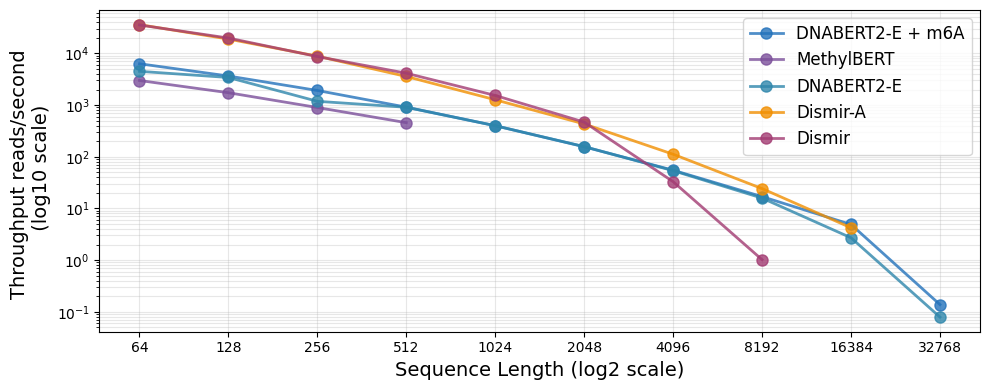

In [57]:
# Process data
model_data = defaultdict(lambda: defaultdict(list))

for model, seq_len, vram, batch_size, num_samples, time_elapsed, used_memory, throughput in results:
    if model == "DNABERT2":
        model = "DNABERT2-E"
    elif model =="DNABERT2M6A":
        model = "DNABERT2-E + m6A"
    elif model == "DISMIR":
        model = "Dismir"
    elif model == "DISMIR_MINIGRU":
        model = "Dismir-A"
    model_data[model][seq_len].append({
        'throughput': throughput,
        'memory': used_memory / 1024  # Convert MB to GB
    })

# Calculate max memory and average throughput for each model and seq_len
processed_data = defaultdict(dict)
for model, seq_lens in model_data.items():
    for seq_len, measurements in seq_lens.items():
        memories = [m['memory'] for m in measurements]
        throughputs = [m['throughput'] for m in measurements]
        
        processed_data[model][seq_len] = {
            'max_memory': max(memories),
            'avg_throughput': np.mean(throughputs)
        }

# Create figure
fig, ax = plt.subplots(figsize=(10, 4))

# Color palette for different models
# colors = plt.cm.tab10(np.linspace(0, 1, len(processed_data)))
colors = ["#2372BB", '#7B4F9A', '#2E86AB','#F18F01', '#A23B72']
model_colors = {model: color for model, color in zip(processed_data.keys(), colors)}

# Plot data for each model
for model, seq_data in processed_data.items():
    # Sort by sequence length
    sorted_data = sorted(seq_data.items())
    
    seq_lens = [item[0] for item in sorted_data]
    throughputs = [item[1]['avg_throughput'] for item in sorted_data]
    max_memories = [item[1]['max_memory'] for item in sorted_data]
    
    # Convert sequence lengths to log2 scale for x-axis
    x_positions = np.log2(seq_lens)
    
    # Plot line connecting points
    line = ax.plot(x_positions, throughputs, 
                   color=model_colors[model], 
                   marker='o', 
                   markersize=8,
                   linewidth=2,
                   label=model,
                   alpha=0.8)
    
    # # Add memory labels at each point
    # for x, y, mem in zip(x_positions, throughputs, max_memories):
    #     ax.annotate(f'{mem:.1f} GB', 
    #                xy=(x, y), 
    #                xytext=(5, 5), 
    #                textcoords='offset points',
    #                fontsize=9,
    #                bbox=dict(boxstyle="round,pad=0.3", 
    #                         facecolor=model_colors[model], 
    #                         alpha=0.3))

# Set x-axis
all_seq_lens = sorted(set(seq_len for seq_data in processed_data.values() for seq_len in seq_data.keys()))
x_ticks = np.log2(all_seq_lens)
ax.set_xticks(x_ticks)
ax.set_xticklabels([str(seq_len) for seq_len in all_seq_lens])
ax.set_xlabel('Sequence Length (log2 scale)', fontsize=14)

# Set y-axis to log10 scale
ax.set_yscale('log')
ax.set_ylabel('Throughput reads/second \n (log10 scale)', fontsize=14)

# Add title and legend
# ax.set_title('Throughput vs Sequence Length with Max Memory Usage', fontsize=16)
ax.legend(loc='best', fontsize=12)

# Add grid for better readability
ax.grid(True, which="both", ls="-", alpha=0.3)

# Adjust layout
plt.tight_layout()
plt.show()

In [60]:
pd.DataFrame(results, columns=["model", "seq_len", "vram", "batch_size", "num_samples", "time_ellapsed", "used_memory","throughput"])

,model,seq_len,vram,batch_size,num_samples,time_ellapsed,used_memory,throughput
0,DNABERT2M6A,32768,10,1,10,72.681235,11500,0.137587
1,DNABERT2M6A,16384,8,3,30,6.136830,9158,4.888517
2,DNABERT2M6A,8192,8,12,120,7.086094,9238,16.934575
3,DNABERT2M6A,4096,8,46,460,8.371664,9104,54.947261
4,DNABERT2M6A,2048,8,163,1630,10.425943,9023,156.340772
5,DNABERT2M6A,1024,8,458,4580,11.449191,9416,400.028252
6,DNABERT2M6A,512,8,1074,10740,11.758707,8614,913.365726
7,DNABERT2M6A,256,8,2620,26200,13.639245,11356,1920.927437
8,DNABERT2M6A,128,8,5150,51500,14.063772,8900,3661.890939
9,DNABERT2M6A,64,8,9620,96200,15.209524,8804,6324.984103


In [62]:
1200/900

1.3333333333333333

In [61]:
112/32

3.5

In [39]:
import pickle
with open("benchmark_throughput_data.pkl", "wb") as f:
    pickle.dump(results,f)